In [1]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
import optuna
from matplotlib import pyplot as plt
from pandas import Period
import pickle as pkl
#os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

c:\Users\gotta\Miniconda3\envs\cs230\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cpu


In [3]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_price", "FR_lmp_processed.csv")
DATA_CSV_LOAD = os.path.join("data", "FR_DAM_Load", "FR_load_processed.csv")
DATA_CSV_REN = os.path.join("data", "FR_REN", "FR_ren_processed.csv")
DATA_CSV_LOAD_RT=os.path.join("data", "FR_DAM_Load", "FR_rt_load_processed.csv")
DATA_CSV_REN_RT=os.path.join("data", "FR_REN", "FR_rt_ren_processed.csv")


In [4]:
df_FR = pd.read_csv(DATA_CSV_FR)
load_FR = pd.read_csv(DATA_CSV_LOAD)
ren_FR = pd.read_csv(DATA_CSV_REN)
all_data_DA = pd.merge(df_FR, load_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA = pd.merge(all_data_DA, ren_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA.rename(columns={'MW':'Load_DA','Wind Onshore':'Wind_DA','Solar':'Solar_DA'}, inplace=True)
load_FR_rt = pd.read_csv(DATA_CSV_LOAD_RT)
ren_FR_rt = pd.read_csv(DATA_CSV_REN_RT)
all_data_RT = pd.merge(df_FR, load_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT = pd.merge(all_data_RT, ren_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT.rename(columns={'MW':'Load_RT','Wind Onshore':'Wind_RT','Solar':'Solar_RT'}, inplace=True)

all_data=pd.merge(all_data_DA,all_data_RT,on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour','EUR/MWh'], how='inner')
all_data

,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,Load_DA,Wind_DA,Solar_DA,Load_RT,Wind_RT,Solar_RT
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09,44450.0,4975.31,0.00,43062.00,6076.00,0.00
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72,41300.0,5338.58,0.00,40483.00,6137.00,0.00
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12,40050.0,5702.33,0.00,39207.00,6342.00,0.00
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46,37750.0,5667.94,0.00,37004.00,6355.00,0.00
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66,36600.0,5633.30,0.00,36399.00,6217.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52142,2025-09-30 19:00:00+02:00,2025,9,30,19,+02:00,117.00,49000.0,2435.69,2158.72,49421.41,1939.43,901.85
52143,2025-09-30 20:00:00+02:00,2025,9,30,20,+02:00,106.18,50400.0,2929.19,315.89,50315.77,2445.66,244.45
52144,2025-09-30 21:00:00+02:00,2025,9,30,21,+02:00,83.23,46700.0,3480.47,0.00,47039.08,3116.56,0.00
52145,2025-09-30 22:00:00+02:00,2025,9,30,22,+02:00,73.00,44100.0,3879.11,0.00,45544.52,3422.12,0.00


In [5]:
#Convert hour, day, month into cyclic features
def add_cyclical_features(df):
    df['Date']=pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour']])
    df["DayOfWeek"] = df['Date'].dt.dayofweek
    # Hour of day (0-23)
    df["sin_hour"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["cos_hour"] = np.cos(2 * np.pi * df["Hour"] / 24)

    # Day of week (0-6 or 1-7 depending on your data)
    df["sin_day"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["cos_day"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

    # Month (1-12)
    df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)
    return df
all_data = add_cyclical_features(all_data)


In [6]:
import numpy as np
import pandas as pd

def create_sliding_window_numpy(
        df,
        target_col="EUR/MWh",
        window_days=7,
        forecast_horizon=1,
        rt_cols=["EUR/MWh", "Load_DA", "Solar_DA", "Wind_DA"],
        rt_cyc_cols=["sin_hour", "cos_hour", "sin_day", "cos_day", "sin_month", "cos_month"],
    ):

    df = df.sort_values("Date").reset_index(drop=True)
    hours = 24
    window_size = window_days * hours
    n = len(df)

    # ---- Storage ----
    X_rt_list = []
    X_rt_cyc_list = []
    y_list = []
    y1_list = []
    y7_list = []
    dates = []

    for i in range(window_size, n - forecast_horizon):

        dates.append(df.loc[i, "Date"])

        # =========================================
        # 1️⃣  REAL-TIME WINDOW   (unchanged)
        # =========================================
        rt_stack = [df.loc[i-window_size:i-1, col].values.astype(float)
                    for col in rt_cols]
        X_rt_list.append(np.stack(rt_stack, axis=1))

        rt_cyc_stack = [df.loc[i-window_size:i-1, col].values.astype(float)
                        for col in rt_cyc_cols]
        X_rt_cyc_list.append(np.stack(rt_cyc_stack, axis=1))



        # =========================================
        # 3️⃣  TARGETS (H-hour vector)
        # =========================================
        y_list.append(
            df.loc[i:i+forecast_horizon-1, target_col].values.astype(float)
        )

        y1_list.append(
            df.loc[i-hours:i-hours+forecast_horizon-1, target_col].values.astype(float)
        )

        y7_list.append(
            df.loc[i-7*hours:i-7*hours+forecast_horizon-1, target_col].values.astype(float)
        )

    # ----------- Convert to numpy arrays --------------
    X_rt       = np.array(X_rt_list)       # (N, window, n_rt)
    X_rt_cyc   = np.array(X_rt_cyc_list)   # (N, window, n_rt_cyc)

    y          = np.array(y_list)          # (N, H)
    y_1d       = np.array(y1_list)         # (N, H)
    y_7d       = np.array(y7_list)         # (N, H)
    dates      = np.array(dates)

    # ---- Merge RT windows ----
    X_rt_full = np.concatenate([X_rt, X_rt_cyc], axis=2)  # (N, window, n_rt+n_rt_cyc)



    # =====================================
    # FEATURE MAP (for normalization)
    # =====================================
    feature_map = {
        "rt_cols": rt_cols,
        "rt_cyc_cols": rt_cyc_cols,
        "rt_window_features": {
            "start_idx": 0,
            "end_idx": len(rt_cols)-1
        },
        "rt_cyclic_features": {
            "start_idx": len(rt_cols),
            "end_idx": len(rt_cols)+len(rt_cyc_cols)-1
        },

        "forecast_horizon": forecast_horizon
    }

    return X_rt_full, y, y_1d, y_7d, dates, feature_map


In [7]:
X_rt, y, y_1d, y_7d, dates, feature_map = create_sliding_window_numpy(all_data,
                                                                            target_col="EUR/MWh",
                                                                            window_days=7,
                                                                            forecast_horizon=1)

In [8]:
print("Shapes")
print("X_rt:", X_rt.shape)
print("y:", y.shape)
print("y_1d:", y_1d.shape)
print("y_7d:", y_7d.shape)

Shapes
X_rt: (51978, 168, 10)
y: (51978, 1)
y_1d: (51978, 1)
y_7d: (51978, 1)


In [9]:
def month_based_split_np(
        X_rt,
        y,
        y_1d,
        y_7d,
        dates,
        features_map,
        train_ratio=0.6,
        dev_ratio=0.2,
        seed=42
    ):
    """
    Month-based split for NumPy-array datasets.
    """

    # --- Convert dates to pandas for easy month extraction ---
    dates_pd = pd.to_datetime(dates)
    yearmonth = dates_pd.to_period("M")

    # --- Unique months ---
    all_months = np.array(yearmonth.unique())
    n_months = len(all_months)

    # --- Shuffle months ---
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(all_months)

    # --- Split ---
    n_train = int(train_ratio * n_months)
    n_dev   = int(dev_ratio * n_months)

    train_m = shuffled[:n_train]
    dev_m   = shuffled[n_train : n_train+n_dev]
    test_m  = shuffled[n_train+n_dev :]

    # --- Boolean masks on rows ---
    mask_train = yearmonth.isin(train_m)
    mask_dev   = yearmonth.isin(dev_m)
    mask_test  = yearmonth.isin(test_m)

    # --- Helper to index all arrays ---
    def select(mask):
        return (
            X_rt[mask],
            y[mask],
            y_1d[mask],
            y_7d[mask],
            dates[mask]
        )

    Xrt_tr, y_tr, y1d_tr, y7d_tr, d_tr = select(mask_train)
    Xrt_de, y_de, y1d_de, y7d_de, d_de = select(mask_dev)
    Xrt_te, y_te, y1d_te, y7d_te, d_te = select(mask_test)

    return {
        "train": (Xrt_tr, y_tr, y1d_tr, y7d_tr, d_tr),
        "dev":   (Xrt_de, y_de, y1d_de, y7d_de, d_de),
        "test":  (Xrt_te, y_te, y1d_te, y7d_te, d_te),
        "months": {
            "train": train_m,
            "dev": dev_m,
            "test": test_m
        },
        "feature_map": features_map
    }


In [10]:
splits = month_based_split_np(
    X_rt, y, y_1d, y_7d, dates, feature_map
)
Xrt_train, y_train, y1d_train, y7d_train, dates_train = splits["train"]
Xrt_dev,   y_dev,   y1d_dev,   y7d_dev,   dates_dev   = splits["dev"]
Xrt_test,  y_test,  y1d_test,  y7d_test,  dates_test  = splits["test"]

features_map = splits["feature_map"]


In [11]:

df_price  = all_data[["Time","EUR/MWh"]]

df_rt_load = all_data[["Time","Load_DA"]]
df_rt_ren  = all_data[["Time","Solar_DA","Wind_DA"]]
for df in [df_price, df_rt_load, df_rt_ren]:
    df["Date"] = pd.to_datetime(df["Time"], utc=True)
    df["YearMonth"] = df["Date"].dt.to_period("M")
train_months = splits["months"]["train"]  # <-- from your earlier split

df_price_tr  = df_price[df_price["YearMonth"].isin(train_months)]
df_rt_load_tr = df_rt_load[df_rt_load["YearMonth"].isin(train_months)]
df_rt_ren_tr  = df_rt_ren[df_rt_ren["YearMonth"].isin(train_months)]

stats_dict = {}

def compute_stats(df, cols, container, prefix=""):
    for c in cols:
        arr = df[c].astype(float).values
        container[prefix + c] = {
            "mean": float(np.nanmean(arr)),
            "std":  float(np.nanstd(arr) + 1e-8)
        }

# --- price y ---
compute_stats(df_price_tr, ["EUR/MWh"], stats_dict, prefix="price_")

# --- RT features ---
rt_cols = ["Load_DA", "Solar_DA", "Wind_DA"]
compute_stats(df_rt_load_tr.merge(df_rt_ren_tr, on="Date"), rt_cols, stats_dict, prefix="rt_")




C:\Users\gotta\AppData\Local\Temp\ipykernel_16652\606519030.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date"] = pd.to_datetime(df["Time"], utc=True)
C:\Users\gotta\AppData\Local\Temp\ipykernel_16652\606519030.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["YearMonth"] = df["Date"].dt.to_period("M")
C:\Users\gotta\AppData\Local\Temp\ipykernel_16652\606519030.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["YearMonth"] = df["Date"].dt

In [12]:
def normalize_sets(
    Xrt, y,
    stats_dict,
    feature_map
):
    """
    Normalizes:
      - y using price stats
      - Xrt windowed features (EUR/MWh, Load_RT, Solar_RT, Wind_RT)
      - Xrt cyclic features untouched
      - Xda DA features
      - Xda cyclic features untouched
    """

    # --- Copies ---
    Xrt = Xrt.copy()
    y   = y.copy()

    # -----------------------
    # Normalize y
    # -----------------------
    y_mean = stats_dict["price_EUR/MWh"]["mean"]
    y_std  = stats_dict["price_EUR/MWh"]["std"]
    y = (y - y_mean) / y_std

    # -----------------------
    # Normalize Xrt
    # -----------------------
    rt_cols = feature_map["rt_cols"]
    rt_cyc_cols = feature_map["rt_cyc_cols"]
    start_rt = feature_map["rt_window_features"]["start_idx"]
    end_rt   = feature_map["rt_window_features"]["end_idx"]

    # Windowed RT features (first 4 columns)
    for j, feat in enumerate(rt_cols):
        if feat == "EUR/MWh":
            mean, std = y_mean, y_std
        else:
            mean = stats_dict[f"rt_{feat}"]["mean"]
            std  = stats_dict[f"rt_{feat}"]["std"]

        Xrt[:, :, start_rt + j] = (Xrt[:, :, start_rt + j] - mean) / std

    # Cyclic RT: do nothing

    # Cyclic DA: untouched

    return Xrt, y


In [13]:
Xrt_train_norm, y_train_norm = normalize_sets(
    Xrt_train, y_train,
    stats_dict,
    feature_map
)

Xrt_dev_norm, y_dev_norm = normalize_sets(
    Xrt_dev, y_dev,
    stats_dict,
    feature_map
)

Xrt_test_norm, y_test_norm = normalize_sets(
    Xrt_test, y_test,
    stats_dict,
    feature_map
)

# #Keep prices only (First channel)
# Xrt_train_norm = Xrt_train_norm[:, :, 0:1]
# Xrt_dev_norm = Xrt_dev_norm[:, :, 0:1]
# Xrt_test_norm = Xrt_test_norm[:, :, 0:1]

# # Keep other features only
# Xrt_train_norm = Xrt_train_norm[:, :, 1:]
# Xrt_dev_norm = Xrt_dev_norm[:, :, 1:]
# Xrt_test_norm = Xrt_test_norm[:, :, 1:]

In [14]:
print("Shapes after normalization:")
print("Xrt_train_norm:", Xrt_train_norm.shape)
print("y_train_norm:", y_train_norm.shape)
print("Xrt_dev_norm:", Xrt_dev_norm.shape)
print("y_dev_norm:", y_dev_norm.shape)
print("Xrt_test_norm:", Xrt_test_norm.shape)
print("y_test_norm:", y_test_norm.shape)

Shapes after normalization:
Xrt_train_norm: (31023, 168, 10)
y_train_norm: (31023, 1)
Xrt_dev_norm: (10264, 168, 10)
y_dev_norm: (10264, 1)
Xrt_test_norm: (10691, 168, 10)
y_test_norm: (10691, 1)


In [15]:
#Load predictions from AWS
with open('source\predictions_linear.pkl', 'rb') as f:
    preds_linear=pkl.load(f)
with open('source\predictions_rnn.pkl', 'rb') as f:
    preds_rnn=pkl.load(f)
with open('source\predictions_dnn.pkl', 'rb') as f:
    preds_dnn=pkl.load(f)
with open('source\predictions_cnn.pkl', 'rb') as f:
    preds_cnn=pkl.load(f)
with open('source\predictions_cnn_rnn.pkl', 'rb') as f:
    preds_cnn_rnn=pkl.load(f)

In [16]:

# --- Main: load CSV, prepare sliding windows, normalize, quick experiments ---
SEED = 42
seed_everything(SEED)




In [17]:
def evaluate_model(
    preds,
    y_np,
    y_np_1d,
    y_np_7d,
    stats_dict,
    batch_size,
    device="cpu"
):
    """
    Evaluation for MULTI-STEP forecasting (e.g. H=24).
    y_np must be shape (N, H)
    model outputs (N, H)
    """

    # ----------------------
    # Get normalization stats
    # ----------------------
    mean_FR = stats_dict["price_EUR/MWh"]["mean"]
    std_FR  = stats_dict["price_EUR/MWh"]["std"]



    # ----------------------
    # Denormalize
    # ----------------------
    predictions=preds
    y_np        = y_np        * std_FR + mean_FR

    # ----------------------
    # Metrics (multi-step)
    # ----------------------

    # MAE averaged over all 24 steps
    mae = np.mean(np.abs(predictions - y_np))

    # Median baseline (per horizon)
    median_val = np.median(y_np, axis=0)          # shape (H,)
    mae_median = np.mean(np.abs(median_val - y_np))
    maem = mae / mae_median

    # rMAE using naive (t-24)
    mae_model_1d = mae
    mae_naive_1d = np.mean(np.abs(y_np_1d - y_np))   # y_np_1d is (N,H)
    rMAE_1d = mae_model_1d / mae_naive_1d

    # rMAE using naive (t-168)
    mae_model_7d = mae
    mae_naive_7d = np.mean(np.abs(y_np_7d - y_np))
    rMAE_7d = mae_model_7d / mae_naive_7d



    print(f"MAE: {mae:.4f} | MAEm: {maem:.4f} | rMAE-1d: {rMAE_1d:.4f} | rMAE-7d: {rMAE_7d:.4f}" )

    return {
        "predictions": predictions,
        "MAE": mae,
        "MAEm": maem,
        "rMAE_1d": rMAE_1d,
        "rMAE_7d": rMAE_7d
    }



In [18]:
print("Evaluating on the test set - Linear Regression:")
eval_res_test_linear = evaluate_model(preds_linear, y_test_norm, y1d_test, y7d_test, stats_dict, batch_size=64, device=device)
print("Evaluating on the test set - RNN:")
eval_res_test_rnn = evaluate_model(preds_rnn, y_test_norm, y1d_test, y7d_test, stats_dict, batch_size=64, device=device)
print("Evaluating on the test set - DNN:")
eval_res_test_dnn = evaluate_model(preds_dnn, y_test_norm, y1d_test, y7d_test, stats_dict, batch_size=64, device=device)
print("Evaluating on the test set - CNN:")
eval_res_test_cnn = evaluate_model(preds_cnn, y_test_norm, y1d_test, y7d_test, stats_dict, batch_size=64, device=device)
print("Evaluating on the test set - CNN-RNN:")
eval_res_test_cnn_rnn = evaluate_model(preds_cnn_rnn, y_test_norm, y1d_test, y7d_test, stats_dict, batch_size=64, device=device)

Evaluating on the test set - Linear Regression:
MAE: 17.4080 | MAEm: 0.3118 | rMAE-1d: 0.7857 | rMAE-7d: 0.5671
Evaluating on the test set - RNN:
MAE: 7.4420 | MAEm: 0.1333 | rMAE-1d: 0.3359 | rMAE-7d: 0.2424
Evaluating on the test set - DNN:
MAE: 7.5920 | MAEm: 0.1360 | rMAE-1d: 0.3427 | rMAE-7d: 0.2473
Evaluating on the test set - CNN:
MAE: 7.2150 | MAEm: 0.1292 | rMAE-1d: 0.3257 | rMAE-7d: 0.2350
Evaluating on the test set - CNN-RNN:
MAE: 7.9273 | MAEm: 0.1420 | rMAE-1d: 0.3578 | rMAE-7d: 0.2582


In [19]:

hours_test  = np.arange(eval_res_test_linear["predictions"].shape[0]) % 24

In [20]:
def per_hour_metrics(preds, y,y1d,y7d, hours):
    preds = preds.squeeze()
    y = y.squeeze()
    med=np.median(y)
    mae = np.zeros(24)
    maem=np.zeros(24)
    rmae1 = np.zeros(24)
    rmae7 = np.zeros(24)
    for h in range(24):
        mask = (hours == h)
        mae[h] = np.mean(np.abs(preds[mask] - y[mask]))
        maem[h] = mae[h]/np.mean(np.abs(preds[mask] - med))
        rmae1[h] = mae[h]/np.mean(np.abs(preds[mask] - y1d[mask]))
        rmae7[h] = mae[h]/np.mean(np.abs(preds[mask] - y7d[mask]))
    return mae, maem, rmae1, rmae7


In [21]:
#Per hour prediction for every model
mae_test_hour_linear,maem_test_hour_linear,rmae1_test_hour_linear,rmae7_test_hour_linear  = per_hour_metrics(eval_res_test_linear["predictions"],  y_test,  y1d_test,  y7d_test,  hours_test)
mae_test_hour_dnn, maem_test_hour_dnn, rmae1_test_hour_dnn, rmae7_test_hour_dnn  = per_hour_metrics(eval_res_test_dnn["predictions"],  y_test,  y1d_test,  y7d_test,  hours_test)
mae_test_hour_rnn, maem_test_hour_rnn, rmae1_test_hour_rnn, rmae7_test_hour_rnn  = per_hour_metrics(eval_res_test_rnn["predictions"],  y_test,  y1d_test,  y7d_test,  hours_test)
mae_test_hour_cnn, maem_test_hour_cnn, rmae1_test_hour_cnn, rmae7_test_hour_cnn  = per_hour_metrics(eval_res_test_cnn["predictions"],  y_test,  y1d_test,  y7d_test,  hours_test)
mae_test_hour_cnn_rnn, maem_test_hour_cnn_rnn, rmae1_test_hour_cnn_rnn, rmae7_test_hour_cnn_rnn  = per_hour_metrics(eval_res_test_cnn_rnn["predictions"],  y_test,  y1d_test,  y7d_test,  hours_test)


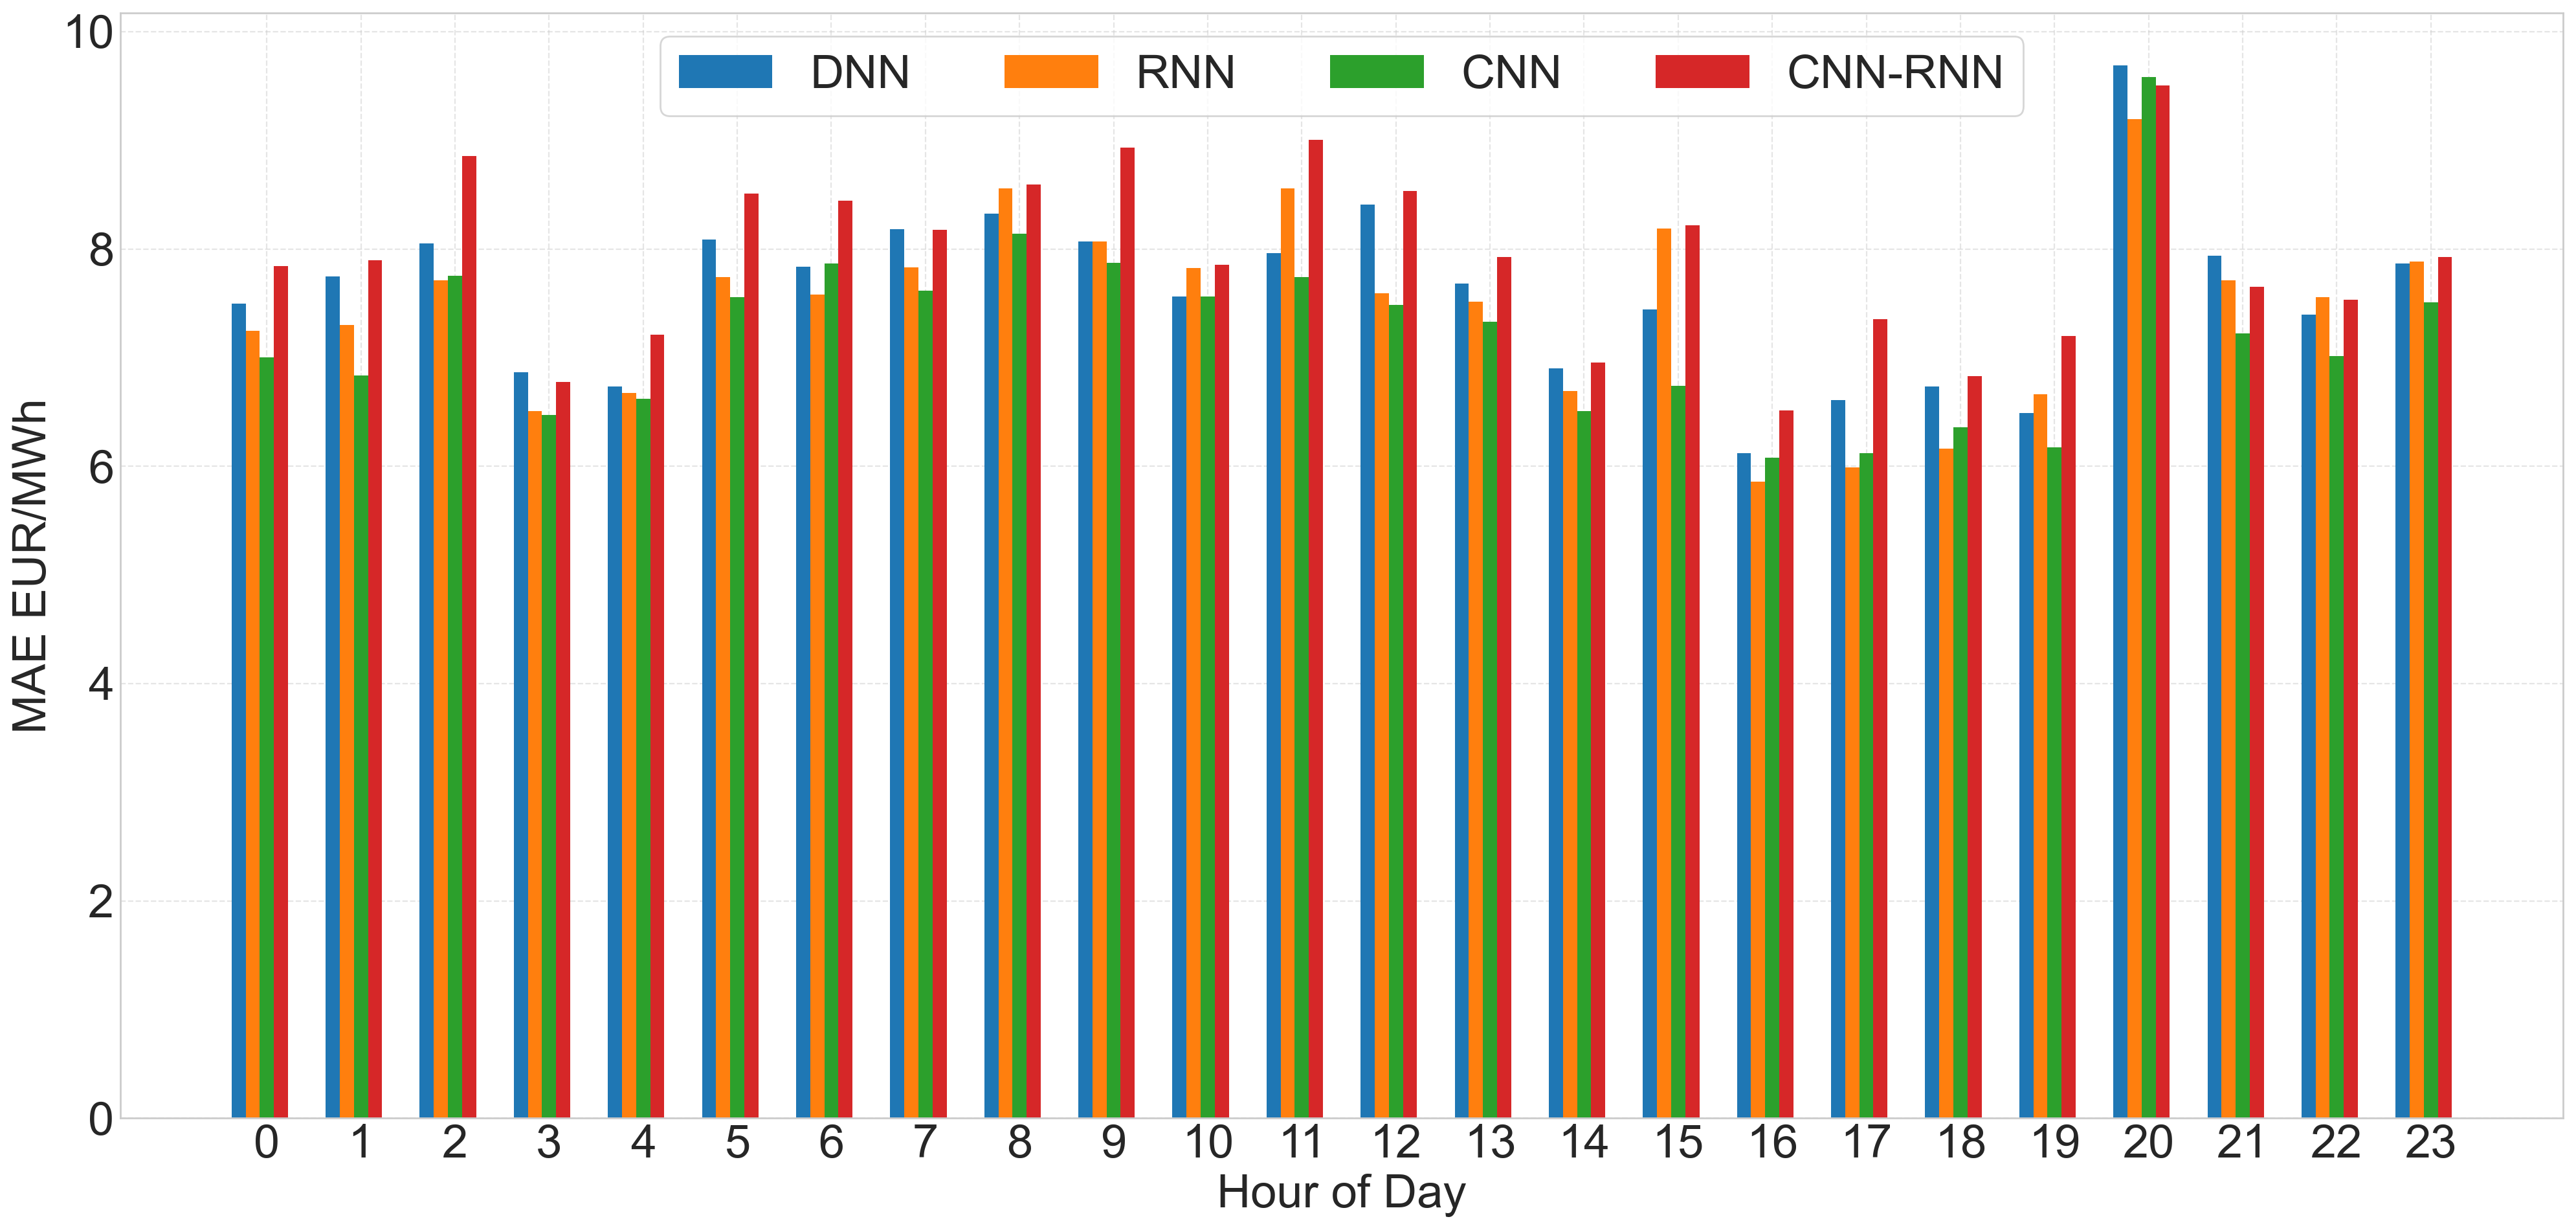

In [22]:
plt.style.use("seaborn-v0_8-whitegrid")

hours = np.arange(24)

metrics = {
    "MAE": {
        # "Linear": mae_test_hour_linear,
        "DNN": mae_test_hour_dnn,
        "RNN": mae_test_hour_rnn,
        "CNN": mae_test_hour_cnn,
        "CNN-RNN": mae_test_hour_cnn_rnn
    }
}

models = ["DNN", "RNN", "CNN", "CNN-RNN"]

colors = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd"   # purple
]

fig, axes = plt.subplots(1, 1, figsize=(20, 10), dpi=200)
axes = [axes]  # Make iterable

for ax, (metric_name, model_data) in zip(axes, metrics.items()):
    
    width = 0.15
    x = hours

    for i, (model, color) in enumerate(zip(models, colors)):
        ax.bar(x + i * width,
               model_data[model],
               width=width,
               label=model,
               color=color)

    ax.set_xlabel("Hour of Day", fontsize=26)
    ax.set_ylabel(metric_name + " EUR/MWh", fontsize=26)

    ax.set_xticks(hours + 2 * width)
    ax.set_xticklabels(hours, fontsize=26)

    ax.tick_params(axis='y', labelsize=26)   # ← HERE

    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(frameon=True, fontsize=26, loc='upper center', ncols=4)

plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


In [23]:
#Plot on the training set
plt.figure(figsize=(12,6))
idx=np.random.randint(0, len(eval_res_train["predictions"])-24)
plt.plot(y_train[idx:idx+24], label="True Prices")
plt.plot(eval_res_train["predictions"][idx:idx+24], label="Predicted Prices")
plt.title("Training Set: True vs Predicted Prices (sample index {})".format(idx))
plt.xlabel("Sample Index")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.show()

NameError: name 'eval_res_train' is not defined

<Figure size 1200x600 with 0 Axes>

In [ ]:
# -----------------------------
# Hyperparameter Tuning (clean)
# -----------------------------

results = {}   # store all results

dropout_values = np.linspace(0.0, 0.5, num=5)
architectures = [(64,1), (64,2), (128,1), (128,2)]

for d in dropout_values:
    for a in architectures:

        hidden_units, layers = a

        print("="*60)
        print(f"Training with dropout={d:.3f}  | hidden={hidden_units}  | layers={layers}")
        print("="*60)

        model, train_hist, val_hist = run_full_train(
            Xrt_train_norm, y_train_norm,      # training data
            Xrt_dev_norm,   y_dev_norm,        # dev data
            hidden_size = hidden_units,
            num_layers   = layers,
            dropout      = d,
            use_batchnorm = False,
            leaky_alpha   = 0,
            learning_rate = 0.001,
            weight_decay  = 0,
            l1_lambda     = 0,
            batch_size    = params["batch_size"],
            epochs        = 20,
            verbose_freq  = 10
        )

        print("Evaluating on dev set...")
        eval_res_dev = evaluate_model(
            model,
            Xrt_dev_norm,
            y_dev_norm,
            y1d_dev,
            y7d_dev,
            stats_dict,
            batch_size=params["batch_size"],
            device=device
        )

        # store clean results
        results[(d, a)] = {
            "MAE"   : eval_res_dev["MAE"],
            "MAEm"  : eval_res_dev["MAEm"],
            "rMAE1" : eval_res_dev["rMAE_1d"],
            "rMAE7" : eval_res_dev["rMAE_7d"],
        }

# -----------------------------
# Extract best configurations
# -----------------------------
min_mae   = min(v["MAE"]   for v in results.values())
min_maem  = min(v["MAEm"]  for v in results.values())
min_rmae1 = min(v["rMAE1"] for v in results.values())
min_rmae7 = min(v["rMAE7"] for v in results.values())

best_configs_mae   = [k for k,v in results.items() if v["MAE"]   == min_mae]
best_configs_maem  = [k for k,v in results.items() if v["MAEm"]  == min_maem]
best_configs_rmae1 = [k for k,v in results.items() if v["rMAE1"] == min_rmae1]
best_configs_rmae7 = [k for k,v in results.items() if v["rMAE7"] == min_rmae7]

print("\n=========== BEST CONFIGURATIONS ===========")
print(f"Best MAE ({min_mae:.4f}):            {best_configs_mae}")
print(f"Best MAEm ({min_maem:.4f}):          {best_configs_maem}")
print(f"Best rMAE-1d ({min_rmae1:.4f}):       {best_configs_rmae1}")
print(f"Best rMAE-7d ({min_rmae7:.4f}):       {best_configs_rmae7}")
print("==========================================\n")


Training with dropout=0.000  | hidden=64  | layers=1
Model:
SimpleRNN(
  (lstm): LSTM(10, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Batch size: 128 Epochs: 20


Epoch 001 | Train MAE: 0.204051 | Val MAE: 0.117707 | LR: 9.944598e-04
Epoch 011 | Train MAE: 0.070391 | Val MAE: 0.084531 | LR: 4.796045e-04
Evaluating on dev set...
MAE: 8.3006 | MAEm: 0.0932 | rMAE-1d: 0.3439 | rMAE-7d: 0.2174
Training with dropout=0.000  | hidden=64  | layers=2
Model:
SimpleRNN(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Batch size: 128 Epochs: 20
Epoch 001 | Train MAE: 0.222588 | Val MAE: 0.125781 | LR: 9.944598e-04
Epoch 011 | Train MAE: 0.070530 | Val MAE: 0.085267 | LR: 4.796045e-04
Evaluating on dev set...
MAE: 8.2899 | MAEm: 0.0931 | rMAE-1d: 0.3

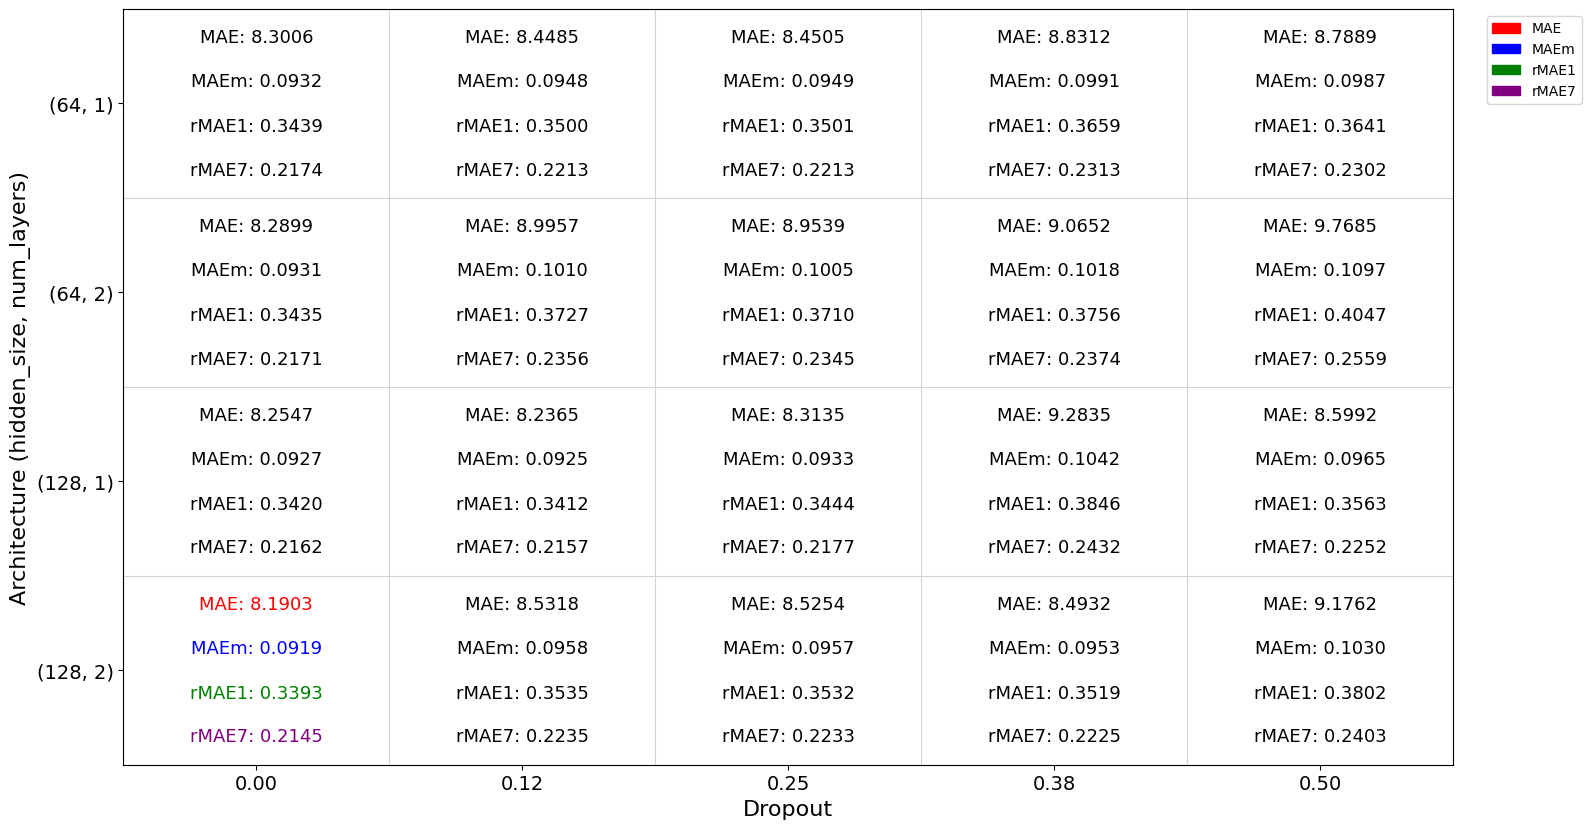

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ----------------------------------------------------
# 1. Extract axes: architectures and dropouts
# ----------------------------------------------------
# keys are (dropout, (hidden, layers))

archs = sorted({arch for (_, arch) in results.keys()},
               key=lambda x: (x[0], x[1]))   # sorted by hidden, layers

drops = sorted({d for (d, _) in results.keys()})   # sorted dropout values

metric_keys = ["MAE", "MAEm", "rMAE1", "rMAE7"]

# ----------------------------------------------------
# 2. Allocate grid for metrics and cell text
# ----------------------------------------------------
grid = {mk: np.full((len(archs), len(drops)), np.nan, dtype=float)
        for mk in metric_keys}

cell_text = [["" for _ in drops] for _ in archs]

# ----------------------------------------------------
# 3. Fill the matrices
# ----------------------------------------------------
for (d, arch), ev in results.items():
    i = archs.index(arch)
    j = drops.index(d)

    # Fill matrices
    for mk in metric_keys:
        grid[mk][i, j] = ev[mk]

    # Build cell text
    cell_text[i][j] = "\n".join(f"{mk}: {ev[mk]:.4f}" for mk in metric_keys)

# ----------------------------------------------------
# 4. Compute minima of each metric
# ----------------------------------------------------
min_positions = {}

for mk in metric_keys:
    mat = grid[mk]

    if np.isnan(mat).all():
        min_positions[mk] = []
        continue

    min_val = np.nanmin(mat)
    rows, cols = np.where(np.isclose(mat, min_val, atol=1e-12))
    min_positions[mk] = list(zip(rows, cols))

# ----------------------------------------------------
# 5. Plotting full grid
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 6 + 0.6 * len(archs)))

ax.set_xlim(-0.5, len(drops) - 0.5)
ax.set_ylim(len(archs) - 0.5, -0.5)

# ticks
ax.set_xticks(range(len(drops)))
ax.set_xticklabels([f"{d:.2f}" for d in drops], fontsize=14)

ax.set_yticks(range(len(archs)))
ax.set_yticklabels([str(a) for a in archs], fontsize=14)

ax.set_xlabel("Dropout", fontsize=16)
ax.set_ylabel("Architecture (hidden_size, num_layers)", fontsize=16)

# grid lines
for x in range(len(drops) + 1):
    ax.axvline(x - 0.5, color="lightgray", linewidth=0.8)
for y in range(len(archs) + 1):
    ax.axhline(y - 0.5, color="lightgray", linewidth=0.8)

# metric colors
colors = ["red", "blue", "green", "purple"]
metric_colors = {metric_keys[i]: colors[i] for i in range(len(metric_keys))}

legend_patches = [
    patches.Patch(color=metric_colors[mk], label=mk) for mk in metric_keys
]

# cell annotation offsets
y_offsets = [-0.35, -0.12, 0.12, 0.35]

# ----------------------------------------------------
# 6. Annotate cells
# ----------------------------------------------------
for i in range(len(archs)):
    for j in range(len(drops)):
        lines = cell_text[i][j].split("\n")

        for k, mk in enumerate(metric_keys):
            line = lines[k] if k < len(lines) else ""
            color = metric_colors[mk] if (i, j) in min_positions[mk] else "black"

            ax.text(j, i + y_offsets[k],
                    line,
                    ha="center", va="center",
                    fontsize=13,
                    color=color)

# legend
ax.legend(handles=legend_patches, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [ ]:
def objective(trial):

    # --- Hyperparameters to tune ---
    hidden_size   = trial.suggest_categorical("hidden_size", [64, 128])
    num_layers    = trial.suggest_categorical("num_layers", [1, 2])
    dropout       = trial.suggest_float("dropout", 0.0, 0.5)
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])
    leaky_alpha   = trial.suggest_float("leaky_alpha", 0.0, 0.2)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    weight_decay  = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    l1_lambda     = trial.suggest_float("l1_lambda", 1e-7, 1e-3, log=True)
    batch_size    = trial.suggest_categorical("batch_size", [64, 128, 256])
    epochs        = 20

    # --- Train ---
    model, train_hist, val_hist = run_full_train(
        Xrt_train_norm, y_train_norm,
        Xrt_dev_norm,   y_dev_norm,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        l1_lambda=l1_lambda,
        batch_size=batch_size,
        epochs=epochs,
        verbose_freq=5,
        device=device
    )

    # --- Evaluate on dev set ---
    metrics = evaluate_model(
        model,
        Xrt_dev_norm,
        y_dev_norm,
        y1d_dev,         # your baseline arrays
        y7d_dev,
        stats_dict,      # contains mean/std for denormalization
        batch_size=batch_size,
        device=device
    )

    mae     = metrics["MAE"]
    maem    = metrics["MAEm"]
    r1      = metrics["rMAE_1d"]
    r7      = metrics["rMAE_7d"]

    return mae, maem, r1, r7


# --- Run the multi-objective study ---
study = optuna.create_study(
    directions=["minimize", "minimize", "minimize", "minimize"],
    study_name="FR_LMP_LSTM_TUNING"
)

study.optimize(objective, n_trials=20)

best_trials = study.best_trials
print(f"Found {len(best_trials)} Pareto-optimal trials.\n")

for t in best_trials:
    print("Values:", t.values)
    print("Params:", t.params)
    print("-" * 60)


[I 2025-11-30 04:28:59,617] A new study created in memory with name: FR_LMP_LSTM_TUNING


Model:
SimpleRNN(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.4454600573226069)
  (dropout): Dropout(p=0.4454600573226069, inplace=False)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0012320891557865779
    lr: 0.0012320891557865779
    maximize: False
    weight_decay: 4.3877729453820454e-05
)
Batch size: 256 Epochs: 20
Epoch 001 | Train MAE: 0.423502 | Val MAE: 0.191776 | LR: 1.225263e-03
Epoch 006 | Train MAE: 0.183616 | Val MAE: 0.116831 | LR: 1.003541e-03
Epoch 011 | Train MAE: 0.163640 | Val MAE: 0.112730 | LR: 5.909155e-04
Epoch 016 | Train MAE: 0.157293 | Val MAE: 0.110377 | LR: 2.290976e-04


[I 2025-11-30 04:29:21,635] Trial 0 finished with values: [10.597406763328022, 0.11897238487934102, 0.43905262021678365, 0.2775702753795446] and parameters: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.4454600573226069, 'use_batchnorm': False, 'leaky_alpha': 0.14512403623120937, 'learning_rate': 0.0012320891557865779, 'weight_decay': 4.3877729453820454e-05, 'l1_lambda': 4.588343105038561e-05, 'batch_size': 256}.


MAE: 10.5974 | MAEm: 0.1190 | rMAE-1d: 0.4391 | rMAE-7d: 0.2776
Model:
SimpleRNN(
  (lstm): LSTM(10, 64, batch_first=True)
  (dropout): Dropout(p=0.26007586695407064, inplace=False)
  (bn_lstm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (bn_fc1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0007432605808471079
    lr: 0.0007432605808471079
    maximize: False
    weight_decay: 0.00015248082791846656
)
Batch size: 256 Epochs: 20
Epoch 001 | Train MAE: 0.501537 | Val MAE: 0.140618 | LR: 7.391427e-04
Epoch 006 | Train MAE: 0.220736 | Val MAE: 0.105592 | LR: 6.053882e-04
Ep

[I 2025-11-30 04:29:36,151] Trial 1 finished with values: [9.323378009454217, 0.10466942919986863, 0.38626936152792357, 0.2442005539041036] and parameters: {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.26007586695407064, 'use_batchnorm': True, 'leaky_alpha': 0.1408141938069836, 'learning_rate': 0.0007432605808471079, 'weight_decay': 0.00015248082791846656, 'l1_lambda': 0.00019419052362233512, 'batch_size': 256}.


...

MAE: 8.9009 | MAEm: 0.0999 | rMAE-1d: 0.3688 | rMAE-7d: 0.2331
Model:
SimpleRNN(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.2813071183154019)
  (dropout): Dropout(p=0.2813071183154019, inplace=False)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001961097291805805
    lr: 0.001961097291805805
    maximize: False
    weight_decay: 0.00011695978955302661
)
Batch size: 64 Epochs: 20
Epoch 001 | Train MAE: 0.247084 | Val MAE: 0.120635 | LR: 1.950232e-03
Epoch 006 | Train MAE: 0.134767 | Val MAE: 0.106138 | LR: 1.597320e-03
Epoch 011 | Train MAE: 0.126003 | Val MAE: 0.109184 | LR: 9.405511e-04
Epoch 016 | Train MAE: 0.121282 | Val MAE: 0.097083 | LR: 3.646510e-04


[I 2025-11-30 04:40:47,135] Trial 18 finished with values: [9.683082990252403, 0.1087076774594927, 0.40117200873695413, 0.2536220485022964] and parameters: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.2813071183154019, 'use_batchnorm': False, 'leaky_alpha': 0.09956571230098073, 'learning_rate': 0.001961097291805805, 'weight_decay': 0.00011695978955302661, 'l1_lambda': 3.8619812671813454e-05, 'batch_size': 64}.


MAE: 9.6831 | MAEm: 0.1087 | rMAE-1d: 0.4012 | rMAE-7d: 0.2536
Model:
SimpleRNN(
  (lstm): LSTM(10, 128, num_layers=2, batch_first=True, dropout=0.3456037420563627)
  (dropout): Dropout(p=0.3456037420563627, inplace=False)
  (bn_lstm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (bn_fc1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.0008048920026040389
    lr: 0.0008048920026040389
    maximize: False
    weight_decay: 4.173110006853702e-06
)
Batch size: 128 Epochs: 20
Epoch 001 | Train MAE: 0.251664 | Val MAE: 0.158028 | LR: 8.004327e-04
Epoch 006 | Train MAE: 0.150

[I 2025-11-30 04:42:10,853] Trial 19 finished with values: [8.954172943677179, 0.10052452770028385, 0.37097312395330656, 0.23453023039308343] and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.3456037420563627, 'use_batchnorm': True, 'leaky_alpha': 0.09261916844981795, 'learning_rate': 0.0008048920026040389, 'weight_decay': 4.173110006853702e-06, 'l1_lambda': 6.374698426801771e-07, 'batch_size': 128}.


MAE: 8.9542 | MAEm: 0.1005 | rMAE-1d: 0.3710 | rMAE-7d: 0.2345
Found 1 Pareto-optimal trials.

Values: [8.21111556760055, 0.09218255214830837, 0.34018811256101017, 0.21506786142805367]
Params: {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.2541330299307926, 'use_batchnorm': False, 'leaky_alpha': 0.08954143004580317, 'learning_rate': 0.0017301665777591376, 'weight_decay': 1.1107576638258875e-05, 'l1_lambda': 9.044917998725486e-07, 'batch_size': 256}
------------------------------------------------------------
